In [2]:
file3 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/all_cluster.tsv'
file4 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/afall_ID50_cluster.tsv'
file5 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/select_cluster.tsv'

In [3]:
rep_seq = {}
rep_fold = {}
seqfile = open(file3,'r')
for line in seqfile:
    key = line.split('\t')[0]
    if key in rep_seq.keys():
        rep_seq[key].append(line.split('\t')[1].split('\n')[0])
    else:
        rep_seq[key] = []
        rep_seq[key].append(line.split('\t')[1].split('\n')[0])
        
foldfile = open(file5,'r')
for line in foldfile:
    key = line.split('\t')[0].split('.')[0]
    if key in rep_fold.keys():
        rep_fold[key].append(line.split('\t')[1].split('.')[0])
    else:
        rep_fold[key] = []
        rep_fold[key].append(line.split('\t')[1].split('.')[0])

In [4]:
len(rep_fold)



3291

In [5]:
def get_pLDDT(pdb_p):
    infile = open(pdb_p,'r')
    pLDDT = []
    for line in infile:
          if line[0:6].rstrip() == 'ATOM' and line[13:15].rstrip() == 'CA':
            pLDDT.append(float(line[60:65].rstrip()))
    infile.close()
    return np.mean(pLDDT)

In [384]:
af_path = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/afnew/'
af_list = os.listdir(af_path)

In [357]:
af_list[0][:-4]

'A1A8S9'

In [391]:
len(id_ec)

392

In [564]:
len(lengthss)

384

In [385]:
lengthss = []
for item in af_list:
    ids = item[:-4]
    lengthss.append(rec_dic[ids])

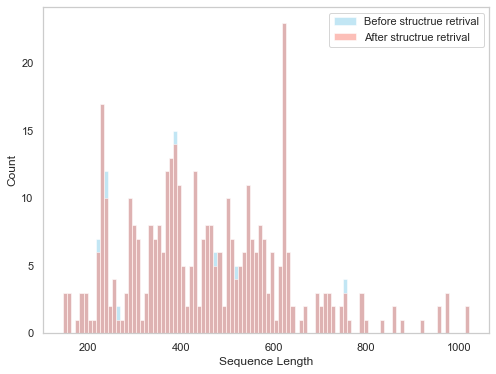

In [388]:
# Plotting the sequence length distribution
plt.figure(figsize=(8, 6))
plt.hist(lengths, bins=100,alpha=0.5, color='skyblue', label='Before structrue retrival')
plt.hist(lengthss, bins=100,alpha=0.5, color='salmon', label='After structrue retrival')
#plt.title('Sequence Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.legend()

plt.grid(False)
plt.show()

In [389]:
all_plddt = []
for item in af_list:
    pdb_p = af_path + item
    all_plddt.append(get_pLDDT(pdb_p))

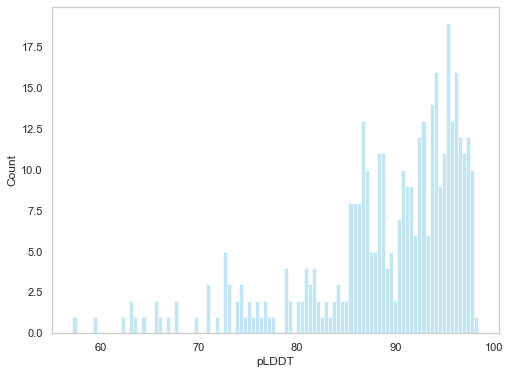

In [390]:
# Plotting the sequence length distribution
plt.figure(figsize=(8, 6))
plt.hist(all_plddt, bins=100,alpha=0.5, color='skyblue')
#plt.title('Sequence Length Distribution')
plt.xlabel('pLDDT')
plt.ylabel('Count')
plt.grid(False)
plt.show()

In [11]:
import os
import numpy as np
af_path = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/afall/'
af_list = os.listdir(af_path)
rep_structure = []
rep_pLDDT = []
keys = []
for key in rep_seq.keys():
    pLDDTs = []
    items = []
    for item in rep_seq[key]:
        item_name = item + '.pdb'
        if item_name in af_list:
            pdb_p = af_path+ item + '.pdb'
            pLDDTs.append(get_pLDDT(pdb_p))
            items.append(item)
    if len(pLDDTs)>0:
        max_plddt = max(pLDDTs)
        rep_pLDDT.append(max_plddt)
        rep_structure.append(items[pLDDTs.index(max_plddt)])
        keys.append(key)

In [6]:
len(rep_seq)

34280

In [427]:
len(fun_fold.values())

3291

In [590]:
members = []

for key in fun_fold.keys():
    
    members.append(len(fun_fold[key]))

In [591]:
members_foldSeq = members

In [593]:
len(members)

3291

In [446]:
members_fliSeq = members

In [596]:
len(uni_fun_true_size)

2283

In [599]:
from collections import Counter

your_list = uni_fun_False_size

counter = Counter(your_list)

segments = [(1,2),(2, 4), (4, 10), (10, 50), (50, 100),(100, 300),(300, 600),(600, 900)]
#segments = [(50, 100),(100, 200),(200, 350),(350, 500),(500, 700),(700, 900)]

segment_counts = {segment: 0 for segment in segments}

for element, count in counter.items():
    for segment in segments:
        if segment[0] <= element < segment[1]:
            segment_counts[segment] += count


for segment, count in segment_counts.items():
    print(f"Numbers in segment {segment}: {count}")



Numbers in segment (1, 2): 0
Numbers in segment (2, 4): 96
Numbers in segment (4, 10): 199
Numbers in segment (10, 50): 343
Numbers in segment (50, 100): 117
Numbers in segment (100, 300): 120
Numbers in segment (300, 600): 78
Numbers in segment (600, 900): 37


In [597]:
uni_fun_true_sizes = segment_counts

In [600]:
uni_fun_False_sizes = segment_counts

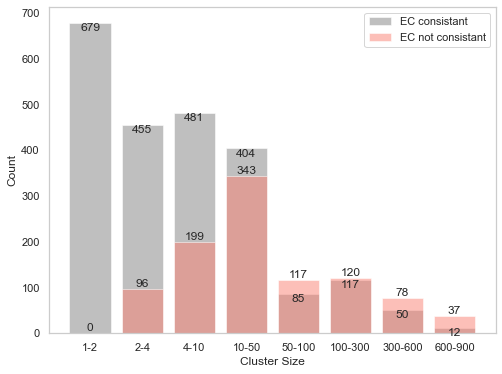

In [604]:
import matplotlib.pyplot as plt

# 将统计结果转换为两个列表，分别包含段和对应的计数
segments_fold, counts_fold = zip(*uni_fun_true_sizes.items())
segments_fli, counts_fli = zip(*uni_fun_False_sizes.items())
# 画柱状图
plt.figure(figsize=(8, 6))
bars_fold = plt.bar(range(len(segments_fold)), counts_fold,color='gray', alpha=0.5,label='EC consistant', tick_label=[f"{segment[0]}-{segment[1]}" for segment in segments])
bars_fli = plt.bar(range(len(segments_fli)), counts_fli,color='salmon', alpha=0.5,label='EC not consistant' , tick_label=[f"{segment[0]}-{segment[1]}" for segment in segments])

plt.xlabel('Cluster Size')
plt.ylabel('Count')
#plt.title('Segmented Counts')
plt.grid(False)
for bar in bars_fold:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='top')
for bar in bars_fli:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')
plt.legend()
plt.show()


In [503]:

1466/3291

0.44545730780917653

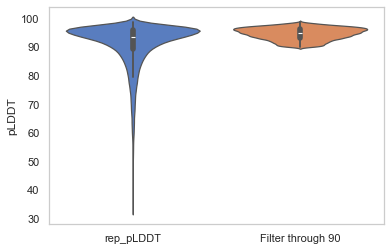

In [497]:
import seaborn as sns
import matplotlib.pyplot as plt

# 两个数据列表
data1 = rep_pLDDT
data2 = [value for index, value in enumerate(rep_pLDDT) if value > 90]

# 使用 Seaborn 绘制两个响铃图在同一个图上
ax = sns.violinplot(data=[data1, data2], palette="muted", orient='v')

#plt.title('Vertical Violin Plot - Data Distribution')
#plt.xlabel('Density')
plt.ylabel('pLDDT')
plt.grid(False)
# 设置 x 轴的刻度和标签
ax.set_xticks([0, 1])
ax.set_xticklabels(['rep_pLDDT', 'Filter through 90'])

plt.show()



In [12]:
len(rep_pLDDT)

31685

In [13]:
len(rep_structure)

31685

In [14]:
len(rep_seq.keys())

34280

In [73]:
threshold_value = 90 


positions = [index for index, value in enumerate(rep_pLDDT) if value > threshold_value]


In [74]:
#outfile= open('/Users/eth-may/Desktop/dtu/semester7/Thesis/data/select_structure.txt','w')
sel_struc=[rep_structure[index ]for index in positions]

In [92]:
sel_keys = [keys[index ]for index in positions]

In [116]:
len(positions)

22980

In [114]:
len(sel_struc)

22980

In [76]:
for item in sel_struc:
    outfile.write(item+'\n')

In [115]:
len(rep_fold)

3291

In [125]:
items = []
for key in fun_fold.keys():
    items.extend(rep_fold[key])

In [126]:
len(items)

22953

In [122]:
if 'P79687' in rep_structure:
    print('1')
else:
    print('2')

2


In [558]:
from CLEAN.utils import *
dirs = "/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/"
id_ec, ec_id =  get_ec_id_dict(dirs+'data/split100' + '.csv')

In [386]:
id_ec, ec_id =  get_ec_id_dict(dirs+'data/new' + '.csv')

In [226]:
len(ec_id)

5242

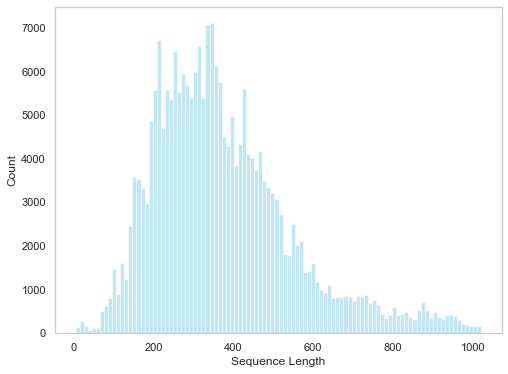

In [367]:
from Bio import SeqIO
import matplotlib.pyplot as plt

def plot_sequence_length_distribution(fasta_file):
    # Read the FASTA file and extract sequence lengths
    lengths = [len(record.seq) for record in SeqIO.parse(fasta_file, "fasta")]

    # Plotting the sequence length distribution
    plt.figure(figsize=(8, 6))
    plt.hist(lengths, bins=100,alpha=0.5, color='skyblue')
    #plt.title('Sequence Length Distribution')
    plt.xlabel('Sequence Length')
    plt.ylabel('Count')
    plt.grid(False)
    plt.show()

# Replace 'your_fasta_file.fasta' with the path to your FASTA file
fasta_file_path = '/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/split100.fasta'
plot_sequence_length_distribution(fasta_file_path)


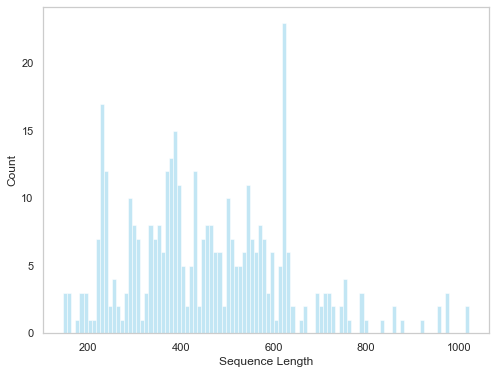

In [329]:
# Replace 'your_fasta_file.fasta' with the path to your FASTA file
fasta_file_path = '/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/new.fasta'
plot_sequence_length_distribution(fasta_file_path)

In [387]:
lengths = [len(record.seq) for record in SeqIO.parse(fasta_file_path, "fasta")]
len(lengths)

392

In [383]:
fasta_file_path = '/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/data/new.fasta'
records = []
rec_dic = {}
for record in SeqIO.parse(fasta_file_path, "fasta"):
    records.append(record)
    rec_dic[record.id] = len(record.seq)

In [334]:
fir_ec = {}
fir_id = {}
for key in ec_id.keys():
    if key[0] in fir_ec.keys() and key[0] in fir_id.keys():
        fir_ec[key[0]].append(key)
        fir_id[key[0]].extend(list(ec_id[key]))
    else:
        fir_ec[key[0]] = [key]
        fir_id[key[0]] = list(ec_id[key])
    
    

In [335]:
len(ec_id)

177

In [336]:
fir_dis = {}
for key in skeys:
    key = str(key)
    fir_dis[key]= []
    for item in fir_id[key]:
        #print(item)
        fir_dis[key].append(rec_dic[item])

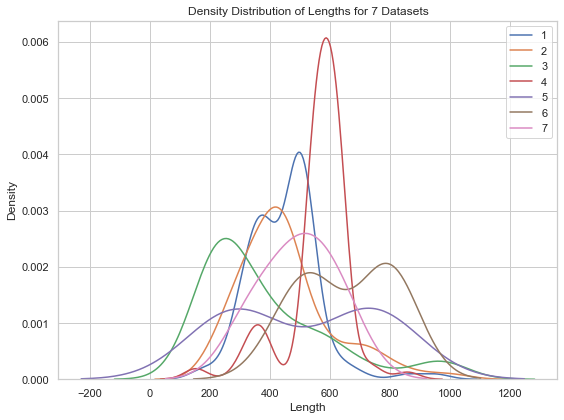

In [337]:
import seaborn as sns
import numpy as np

data1 = fir_dis['1']
data2 = fir_dis['2']
data3 = fir_dis['3']
data4 = fir_dis['4']
data5 = fir_dis['5']
data6 = fir_dis['6']
data7 = fir_dis['7']

# Combine data into a list for seaborn
all_data = [data1, data2, data3, data4, data5, data6, data7]

# Plotting the density distribution of lengths for each dataset using different colors
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))

for i, data in enumerate(all_data, start=1):
    sns.kdeplot(data, label=f'{i}')

plt.xlabel('Length')
plt.ylabel('Density')
plt.title('Density Distribution of Lengths for 7 Datasets')
plt.legend()
plt.tight_layout()
plt.show()


In [338]:
# Dictionary mapping top-level EC numbers to their names
top_ec_numbers = {
    '1': "Oxidoreductases",
    '2': "Transferases",
    '3': "Hydrolases",
    '4': "Lyases",
    '5': "Isomerases",
    '6': "Ligases",
    '7': "Translocases"
    
}

# Create a list of tuples containing EC numbers and their names
ec_list = [(ec_number, ec_name) for ec_number, ec_name in top_ec_numbers.items()]

# Print the list of top-level EC numbers and their names
for ec_number, ec_name in ec_list:
    print(f"{ec_number} - {ec_name}")


1 - Oxidoreductases
2 - Transferases
3 - Hydrolases
4 - Lyases
5 - Isomerases
6 - Ligases
7 - Translocases


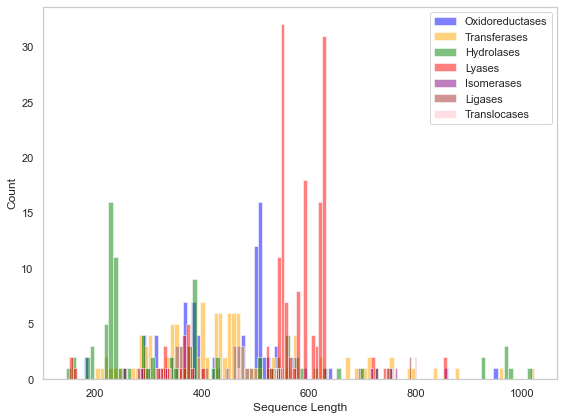

In [341]:
import matplotlib.pyplot as plt
import numpy as np


data1 = fir_dis['1']
data2 = fir_dis['2']
data3 = fir_dis['3']
data4 = fir_dis['4']
data5 = fir_dis['5']
data6 = fir_dis['6']
data7 = fir_dis['7']


# Plotting the distribution of lengths for each dataset using different colors
plt.figure(figsize=(8, 6))
plt.hist(data1, bins=100, alpha=0.5, label=top_ec_numbers['1'], color='blue')
plt.hist(data2, bins=100, alpha=0.5, label=top_ec_numbers['2'], color='orange')
plt.hist(data3, bins=100, alpha=0.5, label=top_ec_numbers['3'], color='green')
plt.hist(data4, bins=100, alpha=0.5, label=top_ec_numbers['4'], color='red')
plt.hist(data5, bins=100, alpha=0.5, label=top_ec_numbers['5'], color='purple')
plt.hist(data6, bins=100, alpha=0.5, label=top_ec_numbers['6'], color='brown')
plt.hist(data7, bins=100, alpha=0.5, label=top_ec_numbers['7'], color='pink')

plt.xlabel('Sequence Length')
plt.ylabel('Count')
#plt.title('Distribution of Lengths for 7 Datasets')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


In [342]:
top_ec_numbers.values()

dict_values(['Oxidoreductases', 'Transferases', 'Hydrolases', 'Lyases', 'Isomerases', 'Ligases', 'Translocases'])

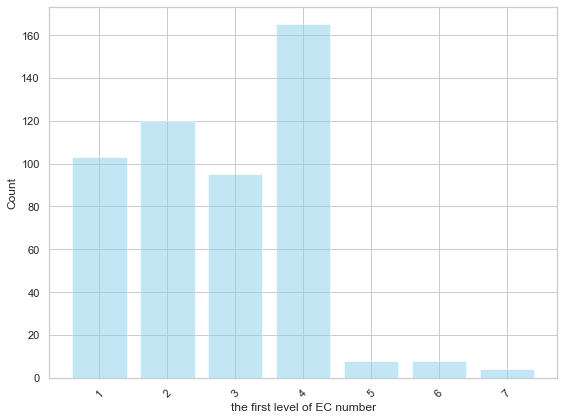

In [343]:
from collections import defaultdict
import matplotlib.pyplot as plt

sample_dict = fir_id

# Dictionary to store key and associated item counts
item_counts = defaultdict(int)


keys = []
# Count the number of items for each key in the dictionary
for key in sample_dict.keys():
    keys.append(int(key))

skeys = np.sort(keys)
items = [len(sample_dict[str(key)]) for key in skeys]



# Plotting the distribution of item counts
plt.figure(figsize=(8, 6))
plt.bar(skeys, items, alpha=0.5,color='skyblue')
plt.xlabel('the first level of EC number')
plt.ylabel('Count')
#plt.title('Number of Items Distribution by Key')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [345]:
items

[44, 43, 30, 50, 3, 5, 2]

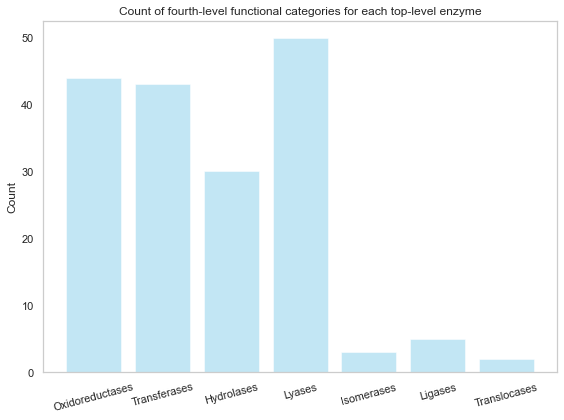

In [344]:
sample_dict = fir_ec

# Dictionary to store key and associated item counts
item_counts = defaultdict(int)


keys = []
# Count the number of items for each key in the dictionary
for key in sample_dict.keys():
    keys.append(int(key))

skeys = np.sort(keys)
items = [len(sample_dict[str(key)]) for key in skeys]



# Plotting the distribution of item counts
plt.figure(figsize=(8, 6))
plt.bar(top_ec_numbers.values(), items, alpha=0.5,color='skyblue')
#plt.xlabel('the first level of EC number')
plt.ylabel('Count')
plt.title('Count of fourth-level functional categories for each top-level enzyme')
plt.grid(False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [347]:
items

[2.340909090909091,
 2.7906976744186047,
 3.1666666666666665,
 3.3,
 2.6666666666666665,
 1.6,
 2.0]

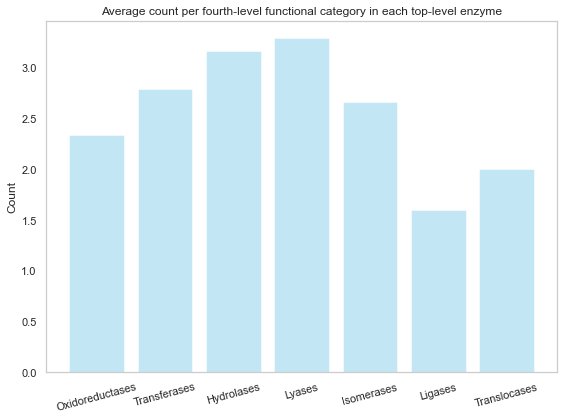

In [346]:
sample_dict = fir_ec

# Dictionary to store key and associated item counts
item_counts = defaultdict(int)


keys = []
# Count the number of items for each key in the dictionary
for key in sample_dict.keys():
    keys.append(int(key))

skeys = np.sort(keys)
items = [len(fir_id[str(key)])/len(fir_ec[str(key)]) for key in skeys]



# Plotting the distribution of item counts
plt.figure(figsize=(8, 6))
plt.bar(top_ec_numbers.values(), items,alpha=0.5, color='skyblue')
#plt.xlabel('the first level of EC number')
plt.ylabel('Count')
plt.title('Average count per fourth-level functional category in each top-level enzyme')
plt.xticks(rotation=15)
plt.grid(False)
plt.tight_layout()
plt.show()

In [432]:
fun_fold = {}
sort_items = []
sel_seq = {}
for key in rep_fold.keys():
    fun_fold[key] = []
    
    for item in rep_fold[key]:
        if item in sel_struc:
            k = sel_keys[sel_struc.index(item)]
            fun_fold[key].extend(rep_seq[k])
            sel_seq[k] = rep_seq[k]
        
            sort_items.extend(rep_seq[k])
        #print(key,item,len(sort_items))
        if item not in sel_struc and len(rep_fold[key])==1:
            fun_fold[key].append(key)
            sort_items.append(key)

In [433]:
len(sort_items)

194521

In [440]:
sel_seq = {}
for item in sel_struc:
    k = sel_keys[sel_struc.index(item)]
    sel_seq[k] = rep_seq[k]

In [521]:
members = []
keys = []
for key in sel_seq.keys():
    keys.append(key)
    members.append(len(sel_seq[key]))

In [522]:
sing_seq = [keys[index] for index, value in enumerate(members) if value == 1]

In [549]:
len(sing_seq)

9027

In [529]:
rep_fold_key = []
rep_fold_item = []
for key in rep_fold.keys():
    for item in rep_fold[key]:
        rep_fold_item.append(item)
        rep_fold_key.append(key)

In [532]:
sing_seq_fold = []
for item in sing_seq:
    if item in rep_fold_item:
        sing_seq_fold.append(rep_fold_key[rep_fold_item.index(item)])
    

In [534]:
counter = Counter(sing_seq_fold)

In [546]:
nums = []
keys = []
for key in counter.keys():
    keys.append(key)
    nums.append(counter[key])
indexs = [keys[index] for index, value in enumerate(nums) if value == 1]

In [547]:
len(indexs)

1105

In [513]:
len(rep_fold)

3291

In [544]:
members = []
keys = []
for key in rep_fold.keys():
    keys.append(key)
    members.append(len(rep_fold[key]))
sing_fold = [keys[index] for index, value in enumerate(members) if value == 1]

In [545]:
len(sing_fold)

1466

In [550]:
len(list(set(sing_fold).intersection(set(indexs))))

677

In [551]:
members = []
keys = []
for key in fun_fold.keys():
    keys.append(key)
    members.append(len(fun_fold[key]))
sing_funfold = [keys[index] for index, value in enumerate(members) if value == 1]

In [552]:
len(sing_funfold)

679

In [570]:
len(fun_fold.keys())

3291

In [571]:
fun_check = {}
fun_key = {}
fold_index = []
fold_items = []
for key in fun_fold.keys():
    fun_key[key] = id_ec[key]
    fun_check[key]= []
    for item in fun_fold[key]:
        fun_check[key].append(id_ec[item])
        fold_index.append(key)
        fold_items.append(item)
    

In [181]:
def get_keys_from_value(dictionary, search_value):
    return [key for key, value in dictionary.items() if search_value in value]

In [572]:
fun_clu = {}
for key in ec_id.keys():
    fun_clu[key] = []
    for item in ec_id[key]:
        if item in fold_items:
            fun_clu[key].append(fold_index[fold_items.index(item)])
    if len(fun_clu[key]) == 0:
        fun_clu.pop(key, None)

In [573]:
len(fun_clu.keys())

4455

In [225]:
ii = []
for key in fun_clu.keys():
    ii.extend(fun_clu[key])
len(ii)

206244

In [574]:

uni_fold = []
for key in fun_clu.keys():
    list_of_lists=fun_clu[key]
    uni_fold.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))


In [575]:
counts = Counter(uni_fold)
for num, count in counts.items():
    print(f"{num}: {count}")

False: 1405
True: 3050


In [578]:
len(uni_fold)

4455

In [576]:
uni_fun = []
for key in fun_check.keys():
    list_of_lists=fun_check[key]
    uni_fun.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))

In [577]:
counts = Counter(uni_fun)
for num, count in counts.items():
    print(f"{num}: {count}")

True: 2283
False: 1008


In [610]:
keys = []
for key in fun_clu.keys():
    keys.append(key)

In [583]:
uni_fun_clu_key = [keys[i] for i in range(len(uni_fun)) if uni_fun[i]]

In [611]:
uni_fold_clu_key = [keys[i] for i in range(len(uni_fold)) if uni_fold[i]]

In [588]:
len(list(set(sing_funfold).intersection(set(uni_fun_clu_key))))

679

In [586]:
len(uni_fun_clu_key)

2283

In [589]:
uni_fun_clu_key_nsingle = []
for item in uni_fun_clu_key:
    if item not in sing_funfold:
        uni_fun_clu_key_nsingle.append(item)

In [623]:
uni_fun_clu_key_nsingle

['A0A0H2ZH52',
 'A0A0H3JX98',
 'A0A1D3PCJ5',
 'A0A1I9R3Y5',
 'A0A1V1FH01',
 'A0A1X9ISN9',
 'A0A2U7XUH7',
 'A0A381HBN1',
 'A0AHG0',
 'A0AK10',
 'A0B742',
 'A0B8A1',
 'A0B9M2',
 'A0JNM6',
 'A0JYU5',
 'A0Q2W0',
 'A0QQ53',
 'A0QRG0',
 'A0QS28',
 'A0QTG2',
 'A0QU81',
 'A0R2E6',
 'A0R3C4',
 'A0R3H2',
 'A0R3R7',
 'A0R5M9',
 'A0R5T2',
 'A0R628',
 'A0REX1',
 'A1DPF0',
 'A1JNT5',
 'A1L1C5',
 'A1R6Q7',
 'A1SG03',
 'A1U0V1',
 'A1ULE3',
 'A1WJU9',
 'A1WWH9',
 'A1WXH5',
 'A1YCA5',
 'A2AV36',
 'A2SQV5',
 'A2STU3',
 'A2SU30',
 'A3DES1',
 'A3DK21',
 'A3DL59',
 'A3DM64',
 'A3DN67',
 'A3GFV3',
 'A3KNL6',
 'A3MWD7',
 'A3PA96',
 'A3SK19',
 'A4FK76',
 'A4G168',
 'A4HYT9',
 'A4J829',
 'A4QFD9',
 'A4TBJ8',
 'A4Y2K7',
 'A4YH38',
 'A4YHJ0',
 'A4YIM8',
 'A5CFG7',
 'A5CWI5',
 'A5E1A0',
 'A5EZZ8',
 'A5F3C5',
 'A5F7V7',
 'A5FRU8',
 'A5FVT7',
 'A5GRN3',
 'A5IJX2',
 'A5IN94',
 'A5INN0',
 'A5MZJ0',
 'A5PLL7',
 'A5U846',
 'A5US42',
 'A5US51',
 'A5UUW9',
 'A5UZV5',
 'A5VLH9',
 'A5W454',
 'A5WDN1',
 'A6LKW9',
 'A6QCX3',


In [636]:
import h5py
proVec_embfile = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Enzyme_proteins_embed_dic'
miss_embvalue = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Miss_proteins_embed_dic'
miss_data = ['P20894', 'A0A0U1LSP0', 'Q03498', 'Q8MU52', 'A0A140CUL9', 'W6JQJ6','B3IVI7', 'Q88QV2']
def load_proVec(lookup):
    if lookup not in miss_data:
        with h5py.File(proVec_embfile , 'r') as hf:
            dataset_name = lookup
            dataset = hf[dataset_name]


            data = dataset[:][0]
    else:
        with h5py.File(miss_embvalue , 'r') as hf:
            dataset_name = lookup
            dataset = hf[dataset_name]


            data = dataset[:][0]

    #torch_data = torch.tensor(data)
    return data #torch_data.unsqueeze(0)


def cos_sim(vector1,vector2):
    # Compute dot product
    dot_product = np.dot(vector1, vector2)

    # Compute magnitudes
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)

    # Compute cosine similarity
    similarity = dot_product / (magnitude1 * magnitude2)
    return similarity



In [637]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def foldseek_clusterProvec(key):
    clusterProvec = []
    for item in fun_fold[key]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def cluster_cos_sim(cluster):

    # Reshape the cluster if needed
    cluster = np.array(cluster).reshape(len(cluster), -1)

    # Compute pairwise cosine similarities
    similarities = cosine_similarity(cluster)

    return similarities


In [638]:
fun_fold_Prosim = {}
for key in fun_fold.keys():
    fun_fold_Prosim[key] = cluster_cos_sim(foldseek_clusterProvec(key))

In [645]:
len(fun_fold_Prosim['A0Q2W0'][0])

19

In [651]:
all_sim = []
True_funClu = []
False_funClu = []
for key in fun_fold_Prosim.keys():
    if key not in sing_funfold:
        all_sim.extend(fun_fold_Prosim[key].flatten())
        if key in uni_fun_clu_key_nsingle:
            True_funClu.extend(fun_fold_Prosim[key].flatten())
        else:
            False_funClu.extend(fun_fold_Prosim[key].flatten())

In [654]:
np.mean(all_sim)

0.9999916

In [655]:
np.mean(True_funClu)

0.99999166

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 两个数据列表
data1 = all_sim
data2 = True_funClu
data3 = False_funClu
# 使用 Seaborn 绘制两个响铃图在同一个图上
ax = sns.violinplot(data=[data1, data2,data3], palette="muted", orient='v')

#plt.title('Vertical Violin Plot - Data Distribution')
#plt.xlabel('Density')
plt.ylabel('cosine similarity')
plt.grid(False)
# 设置 x 轴的刻度和标签
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['All pairs without singletons', 'Pairs within consistant EC annotation clusters','Pairs without consistant EC annotation clusters'])
plt.xticks(rotation=15)
plt.show()


In [594]:
members = []
keys = []
for key in fun_fold.keys():
    keys.append(key)
    members.append(len(fun_fold[key]))
uni_fun_true_size =[members[i] for i in range(len(uni_fun)) if uni_fun[i] ]
uni_fun_False_size =[members[i] for i in range(len(uni_fun)) if uni_fun[i]==False ]

In [615]:
uni_fun_clu_EC = []
for item in uni_fun_clu_key_nsingle:
    uni_fun_clu_EC.append(id_ec[item][0])

In [619]:
counts = Counter(uni_fun_clu_EC)
for num, count in counts.items():
    print(f"{num}: {count}")

7.4.2.9: 1
6.3.1.20: 1
2.3.1.46: 2
1.11.2.3: 2
4.2.1.139: 1
5.5.1.13: 1
5.5.1.6: 2
2.7.7.65: 2
4.1.99.22: 1
2.7.7.72: 6
2.5.1.6: 1
2.1.1.166: 1
3.6.1.27: 3
3.2.1.17: 8
3.1.11.6: 4
2.3.1.222: 1
2.8.2.37: 1
4.2.1.113: 1
3.1.11.5: 1
2.7.8.28: 1
5.4.99.5: 6
2.4.1.266: 1
3.6.1.8: 1
6.3.3.2: 2
6.5.1.1: 2
3.5.1.118: 1
2.4.1.288: 1
3.5.1.9: 2
4.2.2.2: 1
3.1.4.14: 1
4.1.1.97: 2
3.4.25.1: 3
1.13.11.11: 2
3.1.2.6: 2
6.3.2.2: 5
2.3.1.269: 2
4.2.1.96: 2
5.3.3.2: 3
2.7.8.7: 8
2.1.1.321: 1
6.1.1.27: 1
3.1.1.96: 4
5.4.99.12: 3
2.3.2.6: 4
6.3.4.20: 2
3.1.26.5: 19
2.7.7.67: 1
6.1.1.3: 4
3.6.4.13: 4
4.3.2.8: 1
2.7.8.26: 2
4.1.1.19: 5
4.4.1.3: 2
6.3.4.21: 3
1.13.11.54: 2
2.4.2.21: 1
3.2.2.23: 1
3.5.4.16: 5
2.7.1.161: 2
2.7.7.6: 25
3.4.23.36: 3
1.8.4.11: 4
2.7.1.26: 3
3.2.1.26: 1
2.7.7.61: 2
3.5.1.135: 2
5.3.1.23: 2
4.1.1.4: 1
2.1.1.148: 5
3.4.21.88: 1
4.1.1.11: 3
2.3.1.181: 2
1.14.19.77: 1
3.1.3.12: 2
6.1.1.20: 6
6.1.1.10: 4
2.7.1.21: 1
1.14.11.64: 1
2.5.1.75: 1
1.2.1.70: 3
2.4.2.1: 4
3.1.3.64: 1
3.5.1.10

In [617]:
len(list(set(uni_fold_clu_key).intersection(set(uni_fun_clu_EC))))

283

In [567]:
len(fun_check)

3291

In [554]:
len(fun_key)

3291

In [557]:
len(fun_fold)

3291

In [559]:
fun_check = {}
fun_key = {}
fold_index = []
fold_items = []
for key in rep_fold.keys():
    fun_key[key] = id_ec[key]
    fun_check[key]= []
    for item in rep_fold[key]:
        fun_check[key].append(id_ec[item])
        fold_index.append(key)
        fold_items.append(item)
        
fun_clu = {}
for key in ec_id.keys():
    fun_clu[key] = []
    for item in ec_id[key]:
        if item in fold_items:
            fun_clu[key].append(fold_index[fold_items.index(item)])
    if len(fun_clu[key]) == 0:
        fun_clu.pop(key, None)
        
uni_fold = []
for key in fun_clu.keys():
    list_of_lists=fun_clu[key]
    uni_fold.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))

uni_fun = []
for key in fun_check.keys():
    list_of_lists=fun_check[key]
    uni_fun.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))


In [560]:
counts = Counter(uni_fold)
for num, count in counts.items():
    print(f"{num}: {count}")


False: 1292
True: 2684


In [561]:
counts = Counter(uni_fun)
for num, count in counts.items():
    print(f"{num}: {count}")

True: 2404
False: 887
